# Question 2

### Library import

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### EDA

In [4]:
df = pd.read_csv("TimeSeries.csv")

In [10]:
df.head(20)

,Year,Month,Sales
0,2005.0,1,"10,827"
1,NaN,2,"12,049"
2,NaN,3,"18,298"
3,NaN,4,"17,834"
4,NaN,5,"16,480"
5,NaN,6,"16,690"
6,NaN,7,"15,389"
7,NaN,8,"13,031"
8,NaN,9,"17,849"
9,NaN,10,"16,662"


In [7]:
df.shape

(153, 3)

In [9]:
df.isnull().sum()

Year     140
Month      0
Sales      0
dtype: int64

In [11]:
df['Year'] = df['Year'].ffill()

In [12]:
df.head(20)

,Year,Month,Sales
0,2005.0,1,"10,827"
1,2005.0,2,"12,049"
2,2005.0,3,"18,298"
3,2005.0,4,"17,834"
4,2005.0,5,"16,480"
5,2005.0,6,"16,690"
6,2005.0,7,"15,389"
7,2005.0,8,"13,031"
8,2005.0,9,"17,849"
9,2005.0,10,"16,662"


In [14]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))

In [15]:
df = df.set_index('Date')

In [16]:
df

,Year,Month,Sales
Date,,,
2005-01-01,2005.0,1,"10,827"
2005-02-01,2005.0,2,"12,049"
2005-03-01,2005.0,3,"18,298"
2005-04-01,2005.0,4,"17,834"
2005-05-01,2005.0,5,"16,480"
...,...,...,...
2017-05-01,2017.0,5,"31,739"
2017-06-01,2017.0,6,"30,315"
2017-07-01,2017.0,7,"25,046"


In [17]:
df = df[['Sales']]

In [18]:
df.head()

,Sales
Date,
2005-01-01,"10,827"
2005-02-01,"12,049"
2005-03-01,"18,298"
2005-04-01,"17,834"
2005-05-01,"16,480"


In [19]:
df.describe()

,Sales
count,153
unique,151
top,"12,049"
freq,2


In [20]:
df.isnull().sum()

Sales    0
dtype: int64

In [29]:
df.dtypes

Sales    object
dtype: object

In [30]:
df['Sales'] = df['Sales'].astype(str).str.replace(',', '')
df['Sales'] = pd.to_numeric(df['Sales'])

C:\Users\alnur\AppData\Local\Temp\ipykernel_29856\267236078.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sales'] = df['Sales'].astype(str).str.replace(',', '')
C:\Users\alnur\AppData\Local\Temp\ipykernel_29856\267236078.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sales'] = pd.to_numeric(df['Sales'])


In [31]:
df.dtypes

Sales    int64
dtype: object

In [33]:
df.head()

,Sales
Date,
2005-01-01,10827
2005-02-01,12049
2005-03-01,18298
2005-04-01,17834
2005-05-01,16480


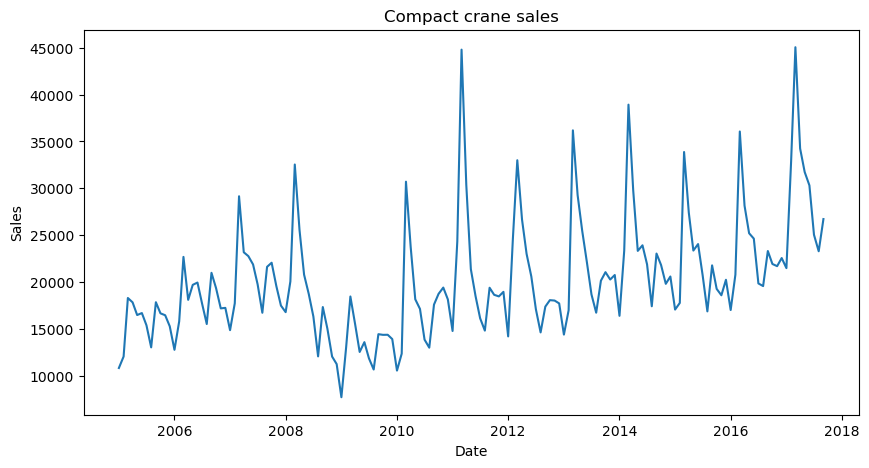

In [34]:
plt.figure(figsize=(10,5))
plt.plot(df["Sales"])
plt.title("Compact crane sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

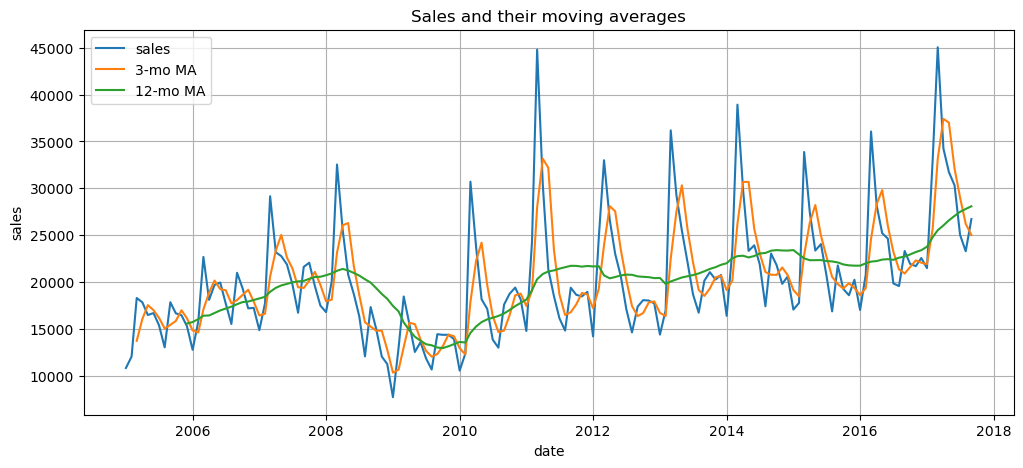

In [46]:
df['MA_3'] = df['Sales'].rolling(3).mean()
df['MA_12'] = df['Sales'].rolling(12).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'], label='sales')
plt.plot(df.index, df['MA_3'], label='3-mo MA')
plt.plot(df.index, df['MA_12'], label='12-mo MA')
plt.title("Sales and their moving averages")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
df_model = df.copy()

In [48]:
df_model['lag_1'] = df_model['Sales'].shift(1)
df_model['lag_2'] = df_model['Sales'].shift(2)
df_model['lag_3'] = df_model['Sales'].shift(3)
df_model['lag_6'] = df_model['Sales'].shift(6)
df_model['lag_12'] = df_model['Sales'].shift(12)

In [49]:
df_model['rolling_mean_3'] = df_model['Sales'].shift(1).rolling(3).mean()
df_model['rolling_mean_6'] = df_model['Sales'].shift(1).rolling(6).mean()

In [50]:
df_model['month'] = df_model.index.month
df_model['quarter'] = df_model.index.quarter

In [51]:
df_model = df_model.dropna()
df_model.head()

,Sales,MA_3,MA_12,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,month,quarter
Date,,,,,,,,,,,,
2006-01-01,12767,14835.000000,15732.250000,15280.0,16458.0,16662.0,15389.0,10827.0,16133.333333,15778.166667,1,1
2006-02-01,15805,14617.333333,16045.250000,12767.0,15280.0,16458.0,13031.0,12049.0,14835.000000,15341.166667,2,1
2006-03-01,22685,17085.666667,16410.833333,15805.0,12767.0,15280.0,17849.0,18298.0,14617.333333,15803.500000,3,1
2006-04-01,18100,18863.333333,16433.000000,22685.0,15805.0,12767.0,16662.0,17834.0,17085.666667,16609.500000,4,2
2006-05-01,19699,20161.333333,16701.250000,18100.0,22685.0,15805.0,16458.0,16480.0,18863.333333,16849.166667,5,2


In [52]:
train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

X_train = train.drop(columns=['Sales', 'MA_3', 'MA_12'], errors='ignore')
y_train = train['Sales']

X_test = test.drop(columns=['Sales', 'MA_3', 'MA_12'], errors='ignore')
y_test = test['Sales']

In [55]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,8
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = model.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [59]:
print(rmse, mae)

3636.887945646842 2372.379324646193


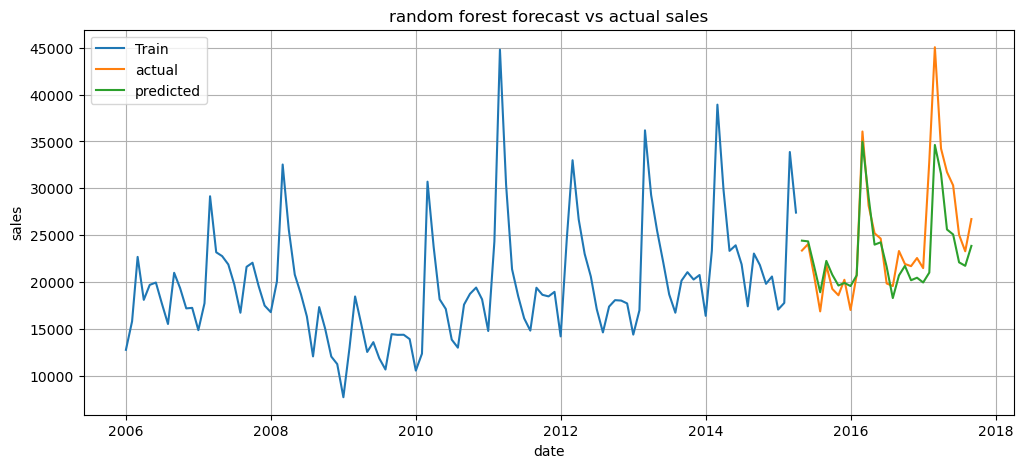

In [61]:
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='actual')
plt.plot(y_test.index, y_pred, label='predicted')
plt.title("random forest forecast vs actual sales")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
future_steps = 6
future_predictions = []

temp_df = df_model.copy()

In [63]:
for i in range(future_steps):
    last_date = temp_df.index[-1]
    next_date = last_date + pd.DateOffset(months=1)

    new_row = pd.DataFrame(index=[next_date])

    new_row['lag_1'] = temp_df['Sales'].iloc[-1]
    new_row['lag_2'] = temp_df['Sales'].iloc[-2]
    new_row['lag_3'] = temp_df['Sales'].iloc[-3]
    new_row['lag_6'] = temp_df['Sales'].iloc[-6]
    new_row['lag_12'] = temp_df['Sales'].iloc[-12]

    new_row['rolling_mean_3'] = temp_df['Sales'].iloc[-3:].mean()
    new_row['rolling_mean_6'] = temp_df['Sales'].iloc[-6:].mean()

    new_row['month'] = next_date.month
    new_row['quarter'] = next_date.quarter

    pred = model.predict(new_row)[0]
    future_predictions.append(pred)

    new_row['Sales'] = pred
    temp_df = pd.concat([temp_df, new_row], axis=0)

In [64]:
future_index = pd.date_range(start=df_model.index[-1] + pd.DateOffset(months=1),
                             periods=future_steps, freq='MS')

In [65]:
future_forecast = pd.DataFrame({ 'Forecast': future_predictions}, index=future_index)
print(future_forecast)

                Forecast
2017-10-01  22221.301867
2017-11-01  20648.095318
2017-12-01  22134.328828
2018-01-01  21178.625958
2018-02-01  33798.038988
2018-03-01  34307.594123


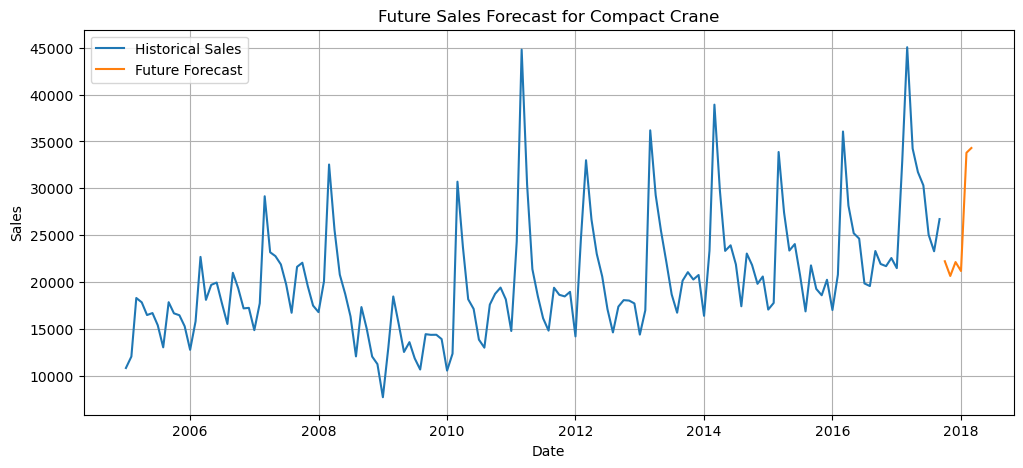

In [66]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'], label='Historical Sales')
plt.plot(future_forecast.index, future_forecast['Forecast'], label='Future Forecast')
plt.title("Future Sales Forecast for Compact Crane")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()